## Customer Segmentation & Churn Risk Analysis
---
**Objective:** Deliver a clean, fully encoded, well-engineered DataFrame ready for clustering.

# Customer Churn Analysis: Data Description

## Context
> "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." — **IBM Sample Data Sets**


### 1. Target Variable
| Column | Description |
| :--- | :--- |
| **Churn** | Indicates if the customer left within the last month (Yes/No). |

### 2. Demographic Information
| Column | Description |
| :--- | :--- |
| **gender** | Whether the customer is a male or a female. |
| **SeniorCitizen** | Whether the customer is a senior citizen (1, 0). |
| **Partner** | Whether the customer has a partner (Yes, No). |
| **Dependents** | Whether the customer has dependents (Yes, No). |

### 3. Services Signed Up For
| Column | Description |
| :--- | :--- |
| **PhoneService** | Whether the customer has a phone service (Yes, No). |
| **MultipleLines** | Whether the customer has multiple lines (Yes, No, No phone service). |
| **InternetService** | Customer’s internet service provider (DSL, Fiber optic, No). |
| **OnlineSecurity** | Whether the customer has online security (Yes, No, No internet service). |
| **OnlineBackup** | Whether the customer has online backup (Yes, No, No internet service). |
| **DeviceProtection** | Whether the customer has device protection (Yes, No, No internet service). |
| **TechSupport** | Whether the customer has tech support (Yes, No, No internet service). |
| **StreamingTV** | Whether the customer has streaming TV (Yes, No, No internet service). |
| **StreamingMovies** | Whether the customer has streaming movies (Yes, No, No internet service). |

### 4. Customer Account Information
| Column | Description |
| :--- | :--- |
| **tenure** | Number of months the customer has stayed with the company. |
| **Contract** | The contract term of the customer (Month-to-month, One year, Two year). |
| **PaperlessBilling** | Whether the customer has paperless billing (Yes, No). |
| **PaymentMethod** | The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)). |
| **MonthlyCharges** | The amount charged to the customer monthly. |
| **TotalCharges** | The total amount charged to the customer. |

---



In [ ]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
import os
import pandas as pd

os.listdir(path)
data = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")



In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.drop("customerID", axis=1, inplace=True)

In [ ]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.isnull().sum()



,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
import numpy as np
data[np.isnan(data['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


ؤ

In [ ]:
data[data['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [ ]:
data.drop(labels=data[data['tenure'] == 0].index, axis=0, inplace=True)
data[data['tenure'] == 0].index

Index([], dtype='int64')

In [ ]:
data.fillna(data["TotalCharges"].mean())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']


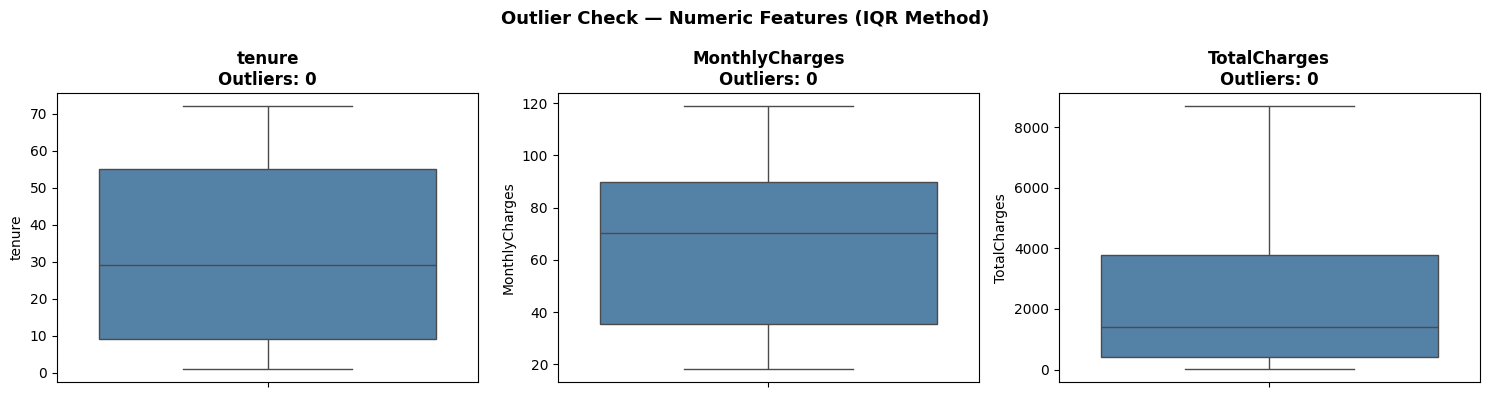

Note: No outliers removed — extreme values represent real high-value customers


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=data[col], ax=ax, color='steelblue')
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)).sum()
    ax.set_title(f'{col}\nOutliers: {outliers}', fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Outlier Check — Numeric Features (IQR Method)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Note: No outliers removed — extreme values represent real high-value customers')

In [ ]:
binary_cols = ['gender', 'Partner', 'Dependents'
, 'PhoneService', 'PaperlessBilling', 'Churn']

mapping = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
}

for col in binary_cols:
    if col in data.columns:
        data[col] = data[col].map(mapping)

print("DataFrame after mapping binary columns:")
print(data[binary_cols].head())

DataFrame after mapping binary columns:
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


In [ ]:
Multi_Class_cols = ['MultipleLines', 'InternetService','StreamingTV' ,
                     'StreamingMovies', 'Contract', 'PaymentMethod']




In [ ]:
data = pd.get_dummies(data, columns=Multi_Class_cols, drop_first=True)


In [ ]:
cols_to_check = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

for col in cols_to_check:
    print(f"Unique values for '{col}': {data[col].unique()}\n")

Unique values for 'OnlineSecurity': ['No' 'Yes' 'No internet service']

Unique values for 'OnlineBackup': ['Yes' 'No' 'No internet service']

Unique values for 'DeviceProtection': ['No' 'Yes' 'No internet service']

Unique values for 'TechSupport': ['No' 'Yes' 'No internet service']



In [ ]:
data = pd.get_dummies(data, columns=cols_to_check, drop_first=True)


In [ ]:
for col in data.select_dtypes(include='bool').columns:
    data[col] = data[col].astype(int)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

In [ ]:
df = data.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import davies_bouldin_score

In [ ]:
X = df.drop("Churn", axis=1) # Features
y = df["Churn"]  # Only for analysis

In [ ]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

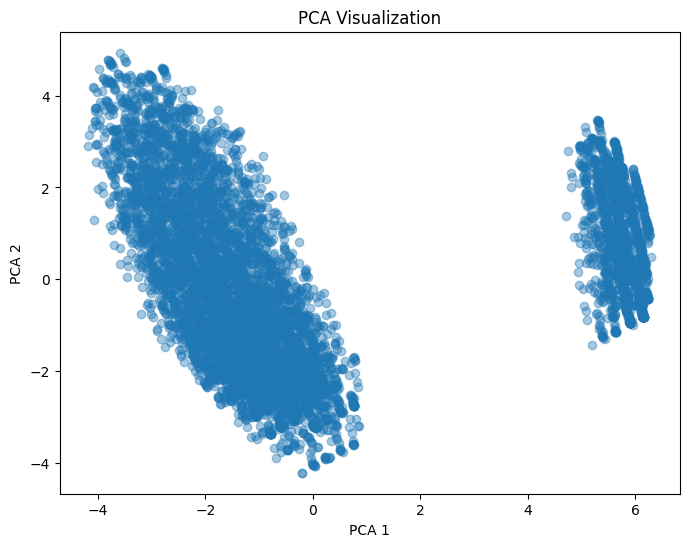

In [ ]:
# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.4
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Visualization")

plt.show()

In [ ]:
print(f"X_scaled shape: {X_scaled.shape}")
print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

X_scaled shape: (7032, 30)
Variance explained by 2 PCs: 45.2%


K=2  |  Inertia=145,616  |  Silhouette=0.3345
K=3  |  Inertia=126,742  |  Silhouette=0.2190
K=4  |  Inertia=111,927  |  Silhouette=0.2377
K=5  |  Inertia=106,335  |  Silhouette=0.1962
K=6  |  Inertia=101,589  |  Silhouette=0.1913
K=7  |  Inertia=98,132  |  Silhouette=0.1383
K=8  |  Inertia=95,112  |  Silhouette=0.1344
K=9  |  Inertia=92,761  |  Silhouette=0.1338
K=10  |  Inertia=90,952  |  Silhouette=0.1294


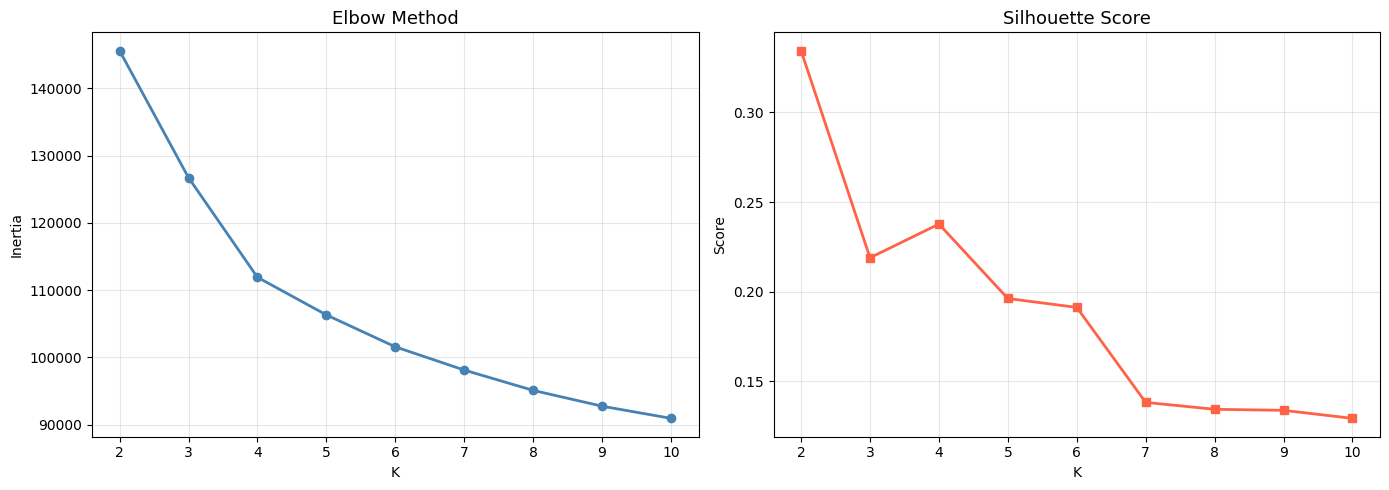


Best K by Silhouette: 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias    = []
silhouettes = []
K_range     = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))
    print(f"K={k}  |  Inertia={km.inertia_:,.0f}  |  Silhouette={silhouettes[-1]:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(list(K_range), silhouettes, 's-', color='tomato', linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=13)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBest K by Silhouette: {list(K_range)[np.argmax(silhouettes)]}")

In [ ]:
from sklearn.metrics import davies_bouldin_score

# Fit final model
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_scaled)

# Metrics
sil = silhouette_score(X_scaled, clusters, sample_size=2000, random_state=42)

print(f"Silhouette Score : {sil:.4f}")



Silhouette Score : 0.3345


In [ ]:
# Cluster sizes
print(f"\nCluster 0 : {(clusters==0).sum()} customer")
print(f"Cluster 1 : {(clusters==1).sum()} customer")



Cluster 0 : 5512 customer
Cluster 1 : 1520 customer


In [ ]:
# Validation using churn
df_val = pd.DataFrame({'Cluster': clusters, 'Churn': y.values})
churn_by_cluster = df_val.groupby('Cluster')['Churn'].mean()
print(f"\nChurn Rate in Cluster 0 : {churn_by_cluster[0]:.1%}")
print(f"Churn Rate in Cluster 1 : {churn_by_cluster[1]:.1%}")


Churn Rate in Cluster 0 : 31.9%
Churn Rate in Cluster 1 : 7.4%


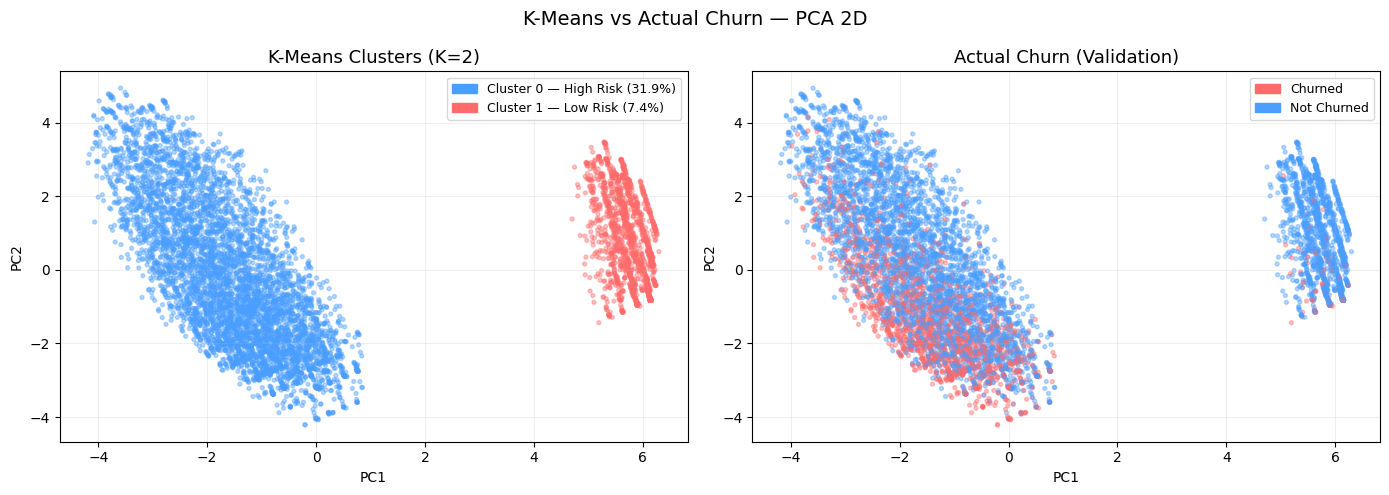

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_cluster = ['#4a9eff' if c == 0 else '#ff6b6b' for c in clusters]
colors_churn   = ['#ff6b6b' if c == 1 else '#4a9eff' for c in y.values]

# Plot 1 — Clusters
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors_cluster, alpha=0.4, s=8)
axes[0].set_title('K-Means Clusters (K=2)', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
p0 = mpatches.Patch(color='#4a9eff', label='Cluster 0 — High Risk (31.9%)')
p1 = mpatches.Patch(color='#ff6b6b', label='Cluster 1 — Low Risk (7.4%)')
axes[0].legend(handles=[p0, p1], fontsize=9)
axes[0].grid(alpha=0.2)

# Plot 2 — Actual Churn
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=colors_churn, alpha=0.4, s=8)
axes[1].set_title('Actual Churn (Validation)', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
p2 = mpatches.Patch(color='#ff6b6b', label='Churned')
p3 = mpatches.Patch(color='#4a9eff', label='Not Churned')
axes[1].legend(handles=[p2, p3], fontsize=9)
axes[1].grid(alpha=0.2)

plt.suptitle('K-Means vs Actual Churn — PCA 2D', fontsize=14)
plt.tight_layout()
plt.show()

**DPSCAN**

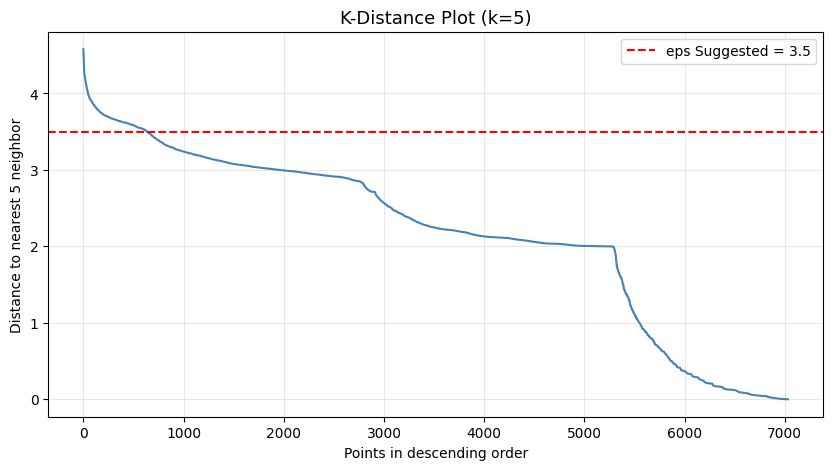

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue', linewidth=1.5)
plt.title('K-Distance Plot (k=5)', fontsize=13)
plt.xlabel('Points in descending order')
plt.ylabel(f'Distance to nearest {k} neighbor')
plt.axhline(y=3.5, color='red', linestyle='--', label='eps Suggested = 3.5') #جديد
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

eps_values = [2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
results    = []
print(f"{'eps':>5} | {'clusters':>8} | {'noise':>6} | {'noise%':>7} | {'silhouette':>10}")
print('-' * 48)

for eps in eps_values:
    db        = DBSCAN(eps=eps, min_samples=k)
    db_labels = db.fit_predict(X_scaled)

    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise    = (db_labels == -1).sum()
    noise_pct  = n_noise / len(db_labels)

    sil = None
    if n_clusters > 1:
        mask = db_labels != -1
        if mask.sum() > 100:
            sil = silhouette_score(X_scaled[mask], db_labels[mask],
                                   sample_size=2000, random_state=42)

    results.append({
        'eps': eps, 'n_clusters': n_clusters,
        'n_noise': n_noise, 'noise_pct': noise_pct,
        'silhouette': sil
    })
    sil_str = f'{sil:.4f}' if sil else 'N/A'
    print(f"{eps:>5.1f} | {n_clusters:>8} | {n_noise:>6} | {noise_pct:>6.1%} | {sil_str:>10}")

results_df = pd.DataFrame(results)
#مش شرط اعلي اسكور يكون احسن مودل ساعات بيكون مضلل علشان ف نويز كتيرة

  eps | clusters |  noise |  noise% | silhouette
------------------------------------------------
  2.0 |      173 |   5241 |  74.5% |     0.7178
  2.5 |       36 |   2202 |  31.3% |    -0.0469
  3.0 |       18 |   1093 |  15.5% |     0.0549
  3.5 |        3 |    157 |   2.2% |     0.2939
  4.0 |        3 |     10 |   0.1% |     0.2908
  5.0 |        2 |      0 |   0.0% |     0.3345


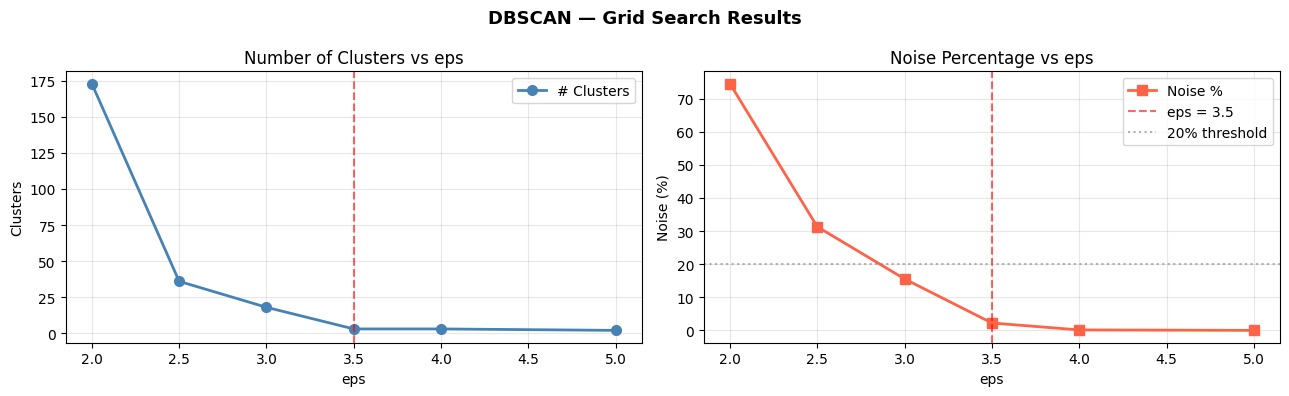

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(eps_values, results_df['n_clusters'], 'o-', color='steelblue',
             linewidth=2, markersize=7, label='# Clusters')
axes[0].set_title('Number of Clusters vs eps', fontsize=12)
axes[0].set_xlabel('eps'); axes[0].set_ylabel('Clusters')
axes[0].axvline(x=3.5, color='red', linestyle='--', alpha=0.6)
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(eps_values, results_df['noise_pct'] * 100, 's-', color='tomato',
             linewidth=2, markersize=7, label='Noise %')
axes[1].set_title('Noise Percentage vs eps', fontsize=12)
axes[1].set_xlabel('eps'); axes[1].set_ylabel('Noise (%)')
axes[1].axvline(x=3.5, color='red', linestyle='--', alpha=0.6, label='eps = 3.5')
axes[1].axhline(y=20,  color='gray', linestyle=':', alpha=0.6, label='20% threshold')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('DBSCAN — Grid Search Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

db = DBSCAN(eps=3.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print(f"Number of Clusters    : {n_clusters}")
print(f"Number of Noise Points : {n_noise} ({n_noise/len(db_labels):.1%})")

mask = db_labels != -1
sil  = silhouette_score(X_scaled[mask], db_labels[mask], sample_size=2000, random_state=42)
print(f"Silhouette    : {sil:.4f}")
print("=" * 45)


Number of Clusters    : 3
Number of Noise Points : 157 (2.2%)
Silhouette    : 0.2939


In [ ]:
df_db = pd.DataFrame({'Cluster': db_labels, 'Churn': y.values})
summary = df_db.groupby('Cluster').agg(
    Count      = ('Churn', 'count'),
    Churn_Rate = ('Churn', 'mean')
).round(3)
summary['Label'] = summary.index.map(lambda x: 'Noise/Outliers' if x == -1 else f'Cluster {x}')
print("\nCluster Summary:")
print(summary[['Label','Count','Churn_Rate']].to_string())


Cluster Summary:
                  Label  Count  Churn_Rate
Cluster                                   
-1       Noise/Outliers    157       0.140
 0            Cluster 0    622       0.262
 1            Cluster 1   4733       0.332
 2            Cluster 2   1520       0.074


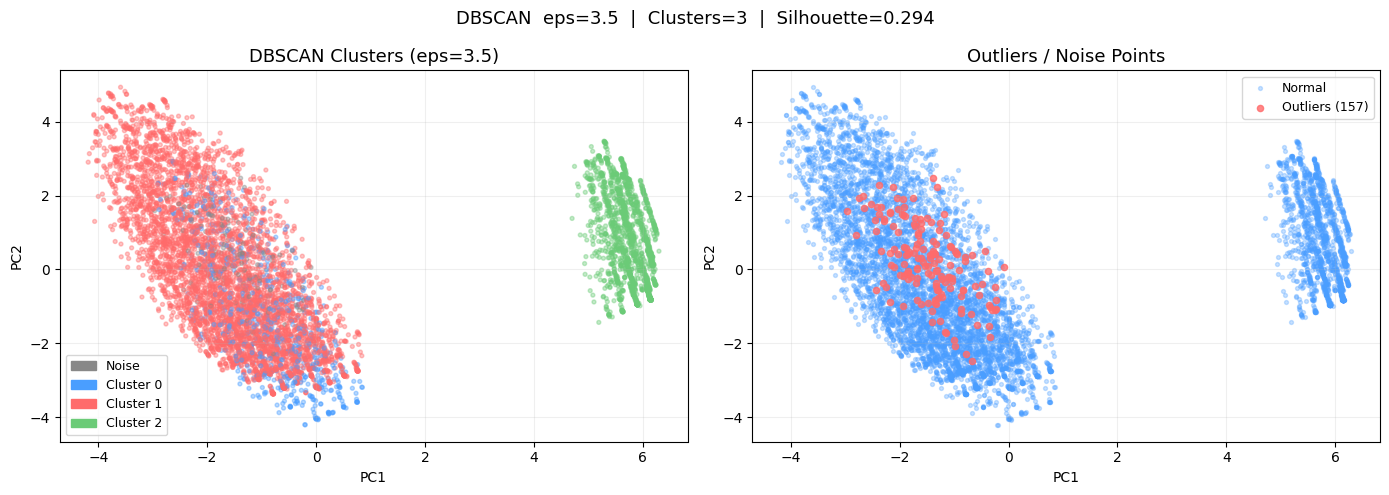

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_map = {-1: '#888888', 0: '#4a9eff', 1: '#ff6b6b', 2: '#6bcb77'}
colors    = [color_map.get(l, '#ffd93d') for l in db_labels]

# Plot 1 — DBSCAN clusters
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=8)
axes[0].set_title('DBSCAN Clusters (eps=3.5)', fontsize=13)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
patches = [mpatches.Patch(color=color_map[k],
           label='Noise' if k==-1 else f'Cluster {k}') for k in sorted(color_map)]
axes[0].legend(handles=patches, fontsize=9)
axes[0].grid(alpha=0.2)

# Plot 2 — Outliers highlighted
noise_mask   = db_labels == -1
normal_mask  = db_labels != -1
axes[1].scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1],
                c='#4a9eff', alpha=0.3, s=8, label='Normal')
axes[1].scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                c='#ff6b6b', alpha=0.8, s=20, label=f'Outliers ({n_noise})')
axes[1].set_title('Outliers / Noise Points', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.suptitle(f'DBSCAN  eps=3.5  |  Clusters={n_clusters}  |  Silhouette={sil:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
!pip install minisom -q

  Preparing metadata (setup.py) ... done


In [ ]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Train SOM
som = MiniSom(
    x=10, y=10,
    input_len=X_scaled.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    random_seed=42
)

# Initialize weights
som.random_weights_init(X_scaled)

# Train
print("Training SOM...")
som.train_random(X_scaled, num_iteration=10000, verbose=True)
print("\nTraining Done!")

# Where everu customer on grid
winner_coordinates = np.array([som.winner(x) for x in X_scaled])
print(f"\nGrid positions shape: {winner_coordinates.shape}")
print(f"Sample positions: {winner_coordinates[:5]}")

Training SOM...
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 2.9343548550041936

Training Done!

Grid positions shape: (7032, 2)
Sample positions: [[0 9]
 [8 9]
 [9 8]
 [3 9]
 [7 2]]


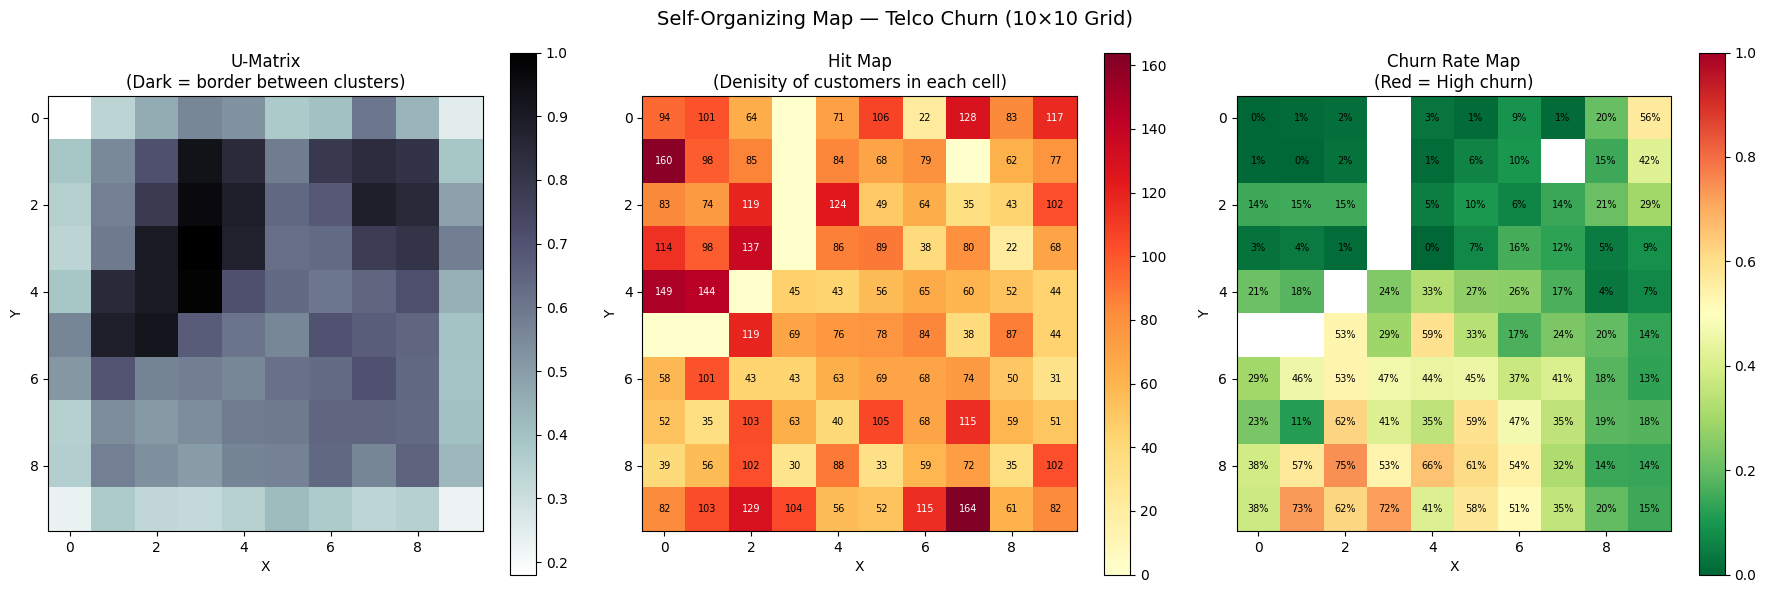

Quantization Error : 2.93
Cells used         : 92 / 100
Max customers/cell : 164
Avg Churn overall  : 26.6%

Top 5 High-Churn cells (min 20 customers):
 Cell  Customers Churn Rate
(0,6)         22       9.1%
(3,9)         68       8.8%
(8,2)        102      74.5%
(9,1)        103      72.8%
(9,3)        104      72.1%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# U-Matrix > distance between neurons
u_matrix = som.distance_map()
im0 = axes[0].imshow(u_matrix, cmap='bone_r', interpolation='nearest')
axes[0].set_title('U-Matrix\n(Dark = border between clusters)', fontsize=12)
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
plt.colorbar(im0, ax=axes[0])

#Hit Map > how many customers in each cell
hit_map = np.zeros((10, 10))
for pos in winner_coordinates:
    hit_map[pos[0], pos[1]] += 1

im1 = axes[1].imshow(hit_map, cmap='YlOrRd', interpolation='nearest')
axes[1].set_title('Hit Map\n(Denisity of customers in each cell)', fontsize=12)
axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
plt.colorbar(im1, ax=axes[1])

# smallest numbers in each cell
for i in range(10):
    for j in range(10):
        if hit_map[i, j] > 0:
            axes[1].text(j, i, int(hit_map[i, j]),
                        ha='center', va='center',
                        fontsize=7, color='black' if hit_map[i,j] < hit_map.max()*0.7 else 'white')

# Churn Map churn rate > in each cell
churn_map   = np.zeros((10, 10))
count_map   = np.zeros((10, 10))
churn_array = y.values

for idx, pos in enumerate(winner_coordinates):
    churn_map[pos[0], pos[1]]  += churn_array[idx]
    count_map[pos[0], pos[1]]  += 1

# Average churn per cell
with np.errstate(divide='ignore', invalid='ignore'):
    avg_churn_map = np.where(count_map > 0, churn_map / count_map, np.nan)

im2 = axes[2].imshow(avg_churn_map, cmap='RdYlGn_r', interpolation='nearest', vmin=0, vmax=1)
axes[2].set_title('Churn Rate Map\n(Red = High churn)', fontsize=12)
axes[2].set_xlabel('X'); axes[2].set_ylabel('Y')
plt.colorbar(im2, ax=axes[2])

# Add churn rate to each cell
for i in range(10):
    for j in range(10):
        if not np.isnan(avg_churn_map[i, j]):
            axes[2].text(j, i, f'{avg_churn_map[i,j]:.0%}',
                        ha='center', va='center',
                        fontsize=7, color='black')

plt.suptitle('Self-Organizing Map — Telco Churn (10×10 Grid)', fontsize=14)
plt.tight_layout()
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print(f"Quantization Error : 2.93")
print(f"Cells used         : {(hit_map > 0).sum()} / 100")
print(f"Max customers/cell : {int(hit_map.max())}")
print(f"Avg Churn overall  : {churn_array.mean():.1%}")
print(f"\nTop 5 High-Churn cells (min 20 customers):")
results = []
for i in range(10):
    for j in range(10):
        if count_map[i,j] >= 20 and not np.isnan(avg_churn_map[i,j]):
            results.append({'Cell': f'({i},{j})',
                          'Customers': int(count_map[i,j]),
                          'Churn Rate': f"{avg_churn_map[i,j]:.1%}"})
results_df = pd.DataFrame(results).sort_values('Churn Rate', ascending=False)
print(results_df.head().to_string(index=False))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#  We divide the grid into 3 regions based on the churn rate
def get_segment(pos, avg_churn_map):
    churn = avg_churn_map[pos[0], pos[1]]
    if np.isnan(churn):
        return 'Unknown'
    elif churn >= 0.5:
        return 'High Risk'
    elif churn >= 0.25:
        return 'Medium Risk'
    else:
        return 'Low Risk'

# Create a segment for each customer
segments = [get_segment(pos, avg_churn_map) for pos in winner_coordinates]
df_som   = pd.DataFrame({
    'Segment'   : segments,
    'Churn'     : y.values,
    'SOM_x'     : winner_coordinates[:, 0],
    'SOM_y'     : winner_coordinates[:, 1],
})

# Summary
print("=" * 50)
print("  SOM Customer Segments")
print("=" * 50)
summary = df_som.groupby('Segment').agg(
    Count      = ('Churn', 'count'),
    Churn_Rate = ('Churn', 'mean'),
).round(3)
summary['Pct'] = (summary['Count'] / len(df_som) * 100).round(1)
print(summary[['Count', 'Pct', 'Churn_Rate']].to_string())

  SOM Customer Segments
             Count   Pct  Churn_Rate
Segment                             
High Risk     1434  20.4       0.611
Low Risk      3933  55.9       0.097
Medium Risk   1665  23.7       0.368


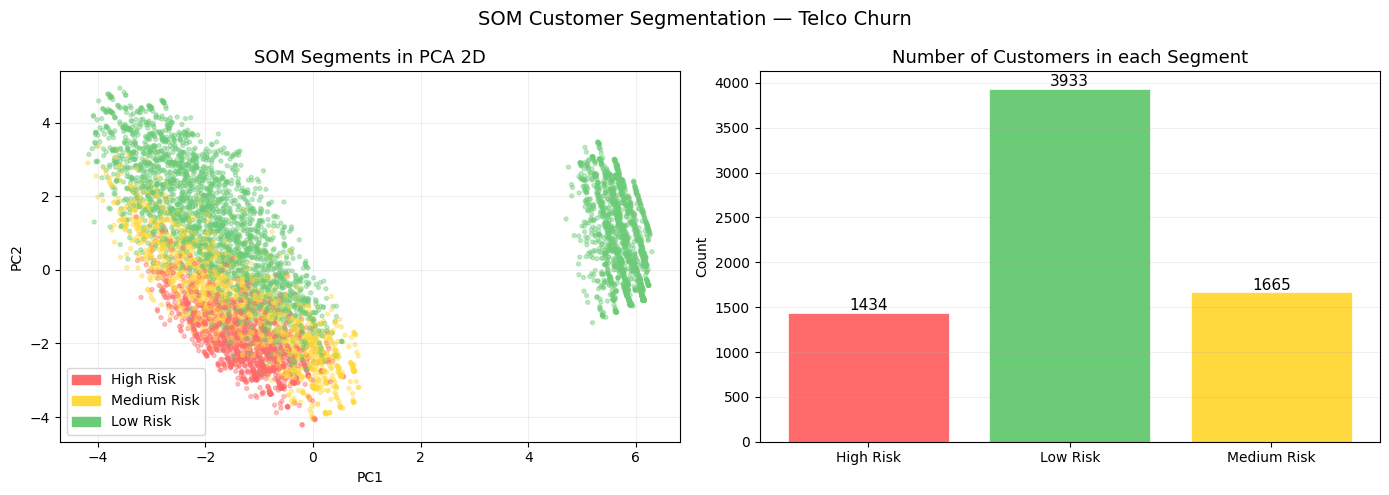

In [ ]:
# Visualization — PCA colored by segment
seg_colors = {
    'High Risk'   : '#ff6b6b',
    'Medium Risk' : '#ffd93d',
    'Low Risk'    : '#6bcb77',
    'Unknown'     : '#888888'
}
colors_seg = [seg_colors[s] for s in segments]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — segments with PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_seg, alpha=0.4, s=8)
axes[0].set_title('SOM Segments in PCA 2D', fontsize=13)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
patches = [mpatches.Patch(color=v, label=k) for k, v in seg_colors.items() if k != 'Unknown']
axes[0].legend(handles=patches, fontsize=10)
axes[0].grid(alpha=0.2)

# Plot 2 — Segment sizes
seg_counts = summary['Count']
axes[1].bar(seg_counts.index, seg_counts.values,
            color=[seg_colors[s] for s in seg_counts.index],
            edgecolor='white', linewidth=0.5)
axes[1].set_title('Number of Customers in each Segment', fontsize=13)
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(seg_counts.items()):
    axes[1].text(i, val + 30, str(val), ha='center', fontsize=11)
axes[1].grid(alpha=0.2, axis='y')

plt.suptitle('SOM Customer Segmentation — Telco Churn', fontsize=14)
plt.tight_layout()
plt.show()

# AutoEncoder

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

#  Model
class Autoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

#  Data
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_tensor  = torch.tensor(X_scaled, dtype=torch.float32).to(device)
dataset   = TensorDataset(X_tensor)
loader    = DataLoader(dataset, batch_size=256, shuffle=True)

In [ ]:
#  Train
model_ae  = Autoencoder(input_dim=X_scaled.shape[1], bottleneck_dim=8).to(device)
optimizer = optim.Adam(model_ae.parameters(), lr=0.001)
criterion = nn.MSELoss()

losses = []
print("Training Autoencoder...")
for epoch in range(1, 101):
    model_ae.train()
    epoch_loss = 0
    for (batch,) in loader:
        optimizer.zero_grad()
        recon, _ = model_ae(batch)
        loss     = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f"  Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

print("\nTraining Done!")

Training Autoencoder...
  Epoch  10 | Loss: 0.4012
  Epoch  20 | Loss: 0.3222
  Epoch  30 | Loss: 0.2932
  Epoch  40 | Loss: 0.2745
  Epoch  50 | Loss: 0.2575
  Epoch  60 | Loss: 0.2456
  Epoch  70 | Loss: 0.2380
  Epoch  80 | Loss: 0.2322
  Epoch  90 | Loss: 0.2263
  Epoch 100 | Loss: 0.2246

Training Done!


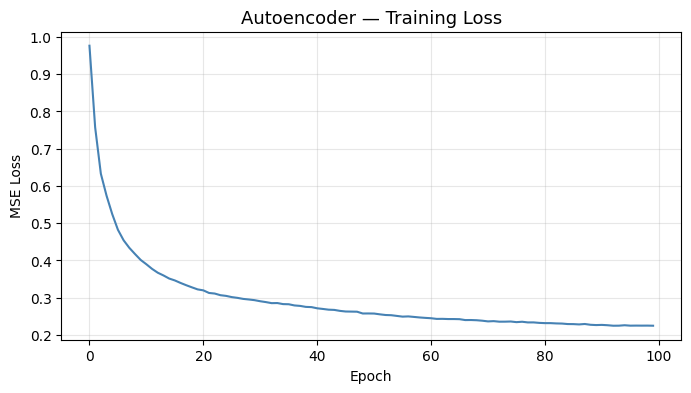

In [ ]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.title('Autoencoder — Training Loss', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Threshold to detect Anomalies
threshold = np.percentile(recon_errors, 95)
anomalies = recon_errors > threshold

print(f"\nThreshold (95th percentile) : {threshold:.4f}")
print(f"Anomalies detected          : {anomalies.sum()} ({anomalies.mean():.1%})")


Threshold (95th percentile) : 0.3078
Anomalies detected          : 352 (5.0%)


In [ ]:
# Validation with Churn
df_ae = pd.DataFrame({
    'Recon_Error' : recon_errors,
    'Anomaly'     : anomalies,
    'Churn'       : y.values
})

print(f"\nChurn Rate in Normal    : {df_ae[~anomalies]['Churn'].mean():.1%}")
print(f"Churn Rate in Anomalies : {df_ae[anomalies]['Churn'].mean():.1%}")


Churn Rate in Normal    : 27.2%
Churn Rate in Anomalies : 14.2%


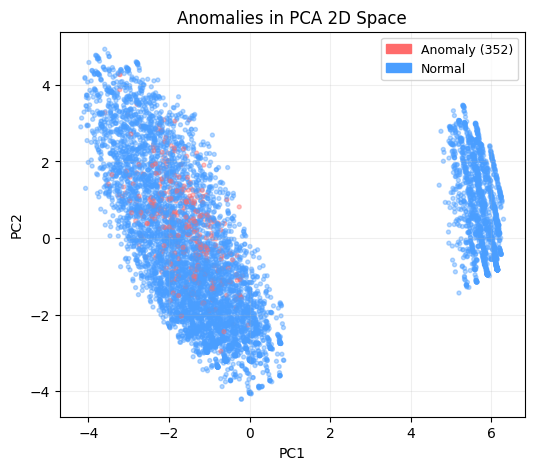

In [ ]:
# Plot 2  Anomalies in PCA space
plt.figure(figsize=(6, 5))

colors_anomaly = ['#ff6b6b' if a else '#4a9eff' for a in anomalies]

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_anomaly, alpha=0.4, s=8)

plt.title('Anomalies in PCA 2D Space', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')

p1 = mpatches.Patch(color='#ff6b6b',label=f'Anomaly ({anomalies.sum()})')
p2 = mpatches.Patch(color='#4a9eff', label='Normal')

plt.legend(handles=[p1, p2], fontsize=9)
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# anomalies are customers with different behavior
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


df_full = pd.DataFrame(X_scaled, columns=pd.read_csv('/content/your_file.csv')
                       .drop(columns=['Churn']).columns
                       if False else [f'f{i}' for i in range(X_scaled.shape[1])])

df_analysis = pd.DataFrame({
    'Recon_Error' : recon_errors,
    'Anomaly'     : anomalies,
    'Churn'       : y.values,
    'tenure'      : df['tenure'].values,
    'MonthlyCharges' : df['MonthlyCharges'].values,
    'TotalCharges'   : df['TotalCharges'].values,
})

#  Normal vs Anomaly
print("=" * 55)
print("  Normal vs Anomaly — Feature Comparison")
print("=" * 55)
comparison = df_analysis.groupby('Anomaly')[['tenure','MonthlyCharges','TotalCharges','Churn']].mean().round(3)
comparison.index = ['Normal', 'Anomaly']
print(comparison.to_string())

# Error threshold > try another values
print("\n\nEffect of Different Thresholds:")
print(f"{'Threshold':>12} {'Anomalies':>12} {'Churn in Anomaly':>18}")
print("-" * 45)
for pct in [90, 92, 95, 97, 99]:
    thr   = np.percentile(recon_errors, pct)
    anoms = recon_errors > thr
    cr    = df_analysis[anoms]['Churn'].mean()
    print(f"  p{pct} = {thr:.3f}  |  {anoms.sum():5d} ({anoms.mean():.1%})  |  {cr:.1%}")

  Normal vs Anomaly — Feature Comparison
         tenure  MonthlyCharges  TotalCharges  Churn
Normal   32.201          64.063      2248.966  0.272
Anomaly  36.614          78.751      2934.876  0.142


Effect of Different Thresholds:
   Threshold    Anomalies   Churn in Anomaly
---------------------------------------------
  p90 = 0.273  |    704 (10.0%)  |  17.0%
  p92 = 0.286  |    563 (8.0%)  |  16.9%
  p95 = 0.308  |    352 (5.0%)  |  14.2%
  p97 = 0.333  |    211 (3.0%)  |  11.8%
  p99 = 0.383  |     71 (1.0%)  |  11.3%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#   Clustering on  Bottleneck Embeddings
print("Clustering on AE Embeddings...")
best_k, best_sil = 2, -1
for k in range(2, 7):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbs = km.fit_predict(embeddings_ae)
    sil = silhouette_score(embeddings_ae, lbs)
    print(f"  K={k} | Silhouette={sil:.4f}")
    if sil > best_sil:
        best_sil, best_k = sil, k

km_ae   = KMeans(n_clusters=best_k, random_state=42, n_init=10)
ae_lbls = km_ae.fit_predict(embeddings_ae)

df_ae_final = pd.DataFrame({'Cluster': ae_lbls, 'Churn': y.values,
                             'Anomaly': anomalies, 'Recon_Error': recon_errors})

print(f"\nBest K: {best_k} | Silhouette: {best_sil:.4f}")
print("\nAE Cluster Summary:")
summary = df_ae_final.groupby('Cluster').agg(
    Count        = ('Churn', 'count'),
    Churn_Rate   = ('Churn', 'mean'),
    Anomaly_Rate = ('Anomaly', 'mean'),
    Avg_Error    = ('Recon_Error', 'mean')
).round(3)
print(summary.to_string())



Clustering on AE Embeddings...
  K=2 | Silhouette=0.2400
  K=3 | Silhouette=0.2252
  K=4 | Silhouette=0.2154
  K=5 | Silhouette=0.2117
  K=6 | Silhouette=0.1935

Best K: 2 | Silhouette: 0.2400

AE Cluster Summary:
         Count  Churn_Rate  Anomaly_Rate  Avg_Error
Cluster                                            
0         3022       0.168         0.029      0.122
1         4010       0.339         0.066      0.170


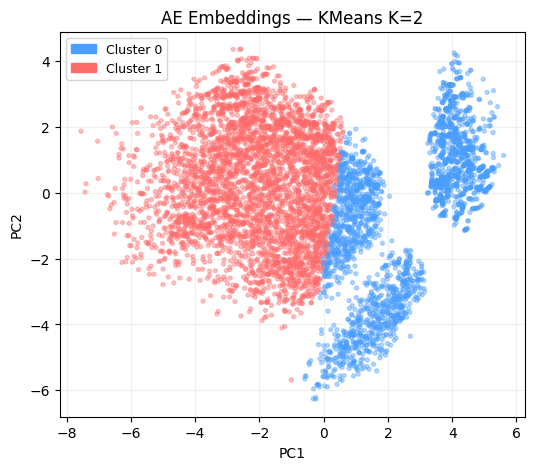

In [ ]:
# AE Clusters
pca_ae = PCA(n_components=2, random_state=42)
ae_2d = pca_ae.fit_transform(embeddings_ae)

COLS = ['#4a9eff','#ff6b6b','#6bcb77','#ffd93d','#c56bff']

plt.figure(figsize=(6, 5))

colors_ae = [COLS[l] for l in ae_lbls]

plt.scatter(ae_2d[:, 0],ae_2d[:, 1],c=colors_ae, alpha=0.4,s=8)
plt.title(f'AE Embeddings — KMeans K={best_k}', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')

patches = [
    mpatches.Patch(color=COLS[i], label=f'Cluster {i}')
    for i in range(best_k)
]

plt.legend(handles=patches, fontsize=9)
plt.grid(alpha=0.2)
plt.show()

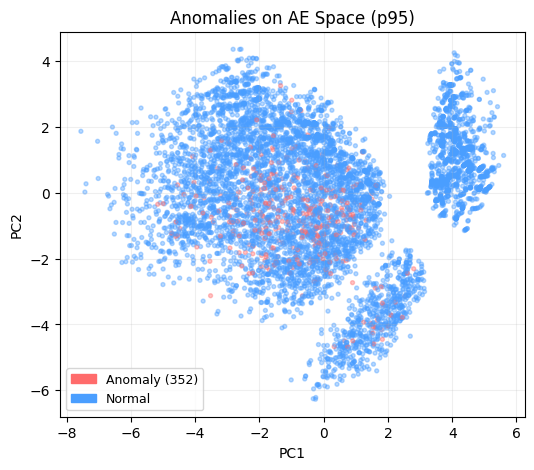

In [ ]:
#  Anomalies on AE Space
plt.figure(figsize=(6, 5))

colors_anom = ['#ff6b6b' if a else '#4a9eff' for a in anomalies]

plt.scatter(ae_2d[:, 0], ae_2d[:, 1],  c=colors_anom, alpha=0.4, s=8)
plt.title('Anomalies on AE Space (p95)', fontsize=12)
plt.xlabel('PC1')
plt.ylabel('PC2')

p1 = mpatches.Patch(color='#ff6b6b',label=f'Anomaly ({anomalies.sum()})')
p2 = mpatches.Patch(color='#4a9eff',label='Normal')

plt.legend(handles=[p1, p2], fontsize=9)
plt.grid(alpha=0.2)
plt.show()

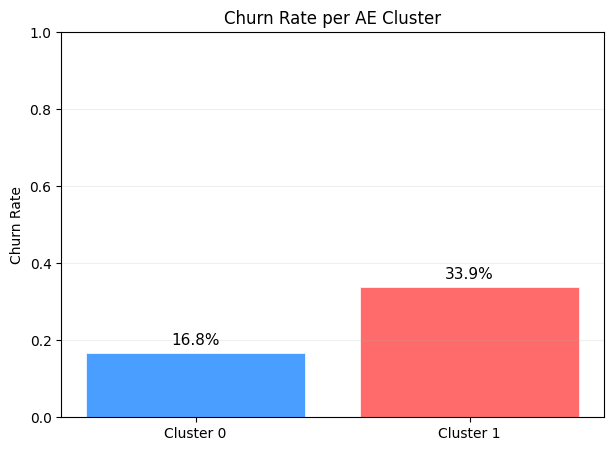

In [ ]:
# Churn Rate per Cluster
plt.figure(figsize=(7, 5))

churn_rates = summary['Churn_Rate']
bars = plt.bar(
    [f'Cluster {i}' for i in churn_rates.index],
    churn_rates.values,color=[COLS[i] for i in churn_rates.index],edgecolor='white',linewidth=0.5)

plt.title('Churn Rate per AE Cluster', fontsize=12)
plt.ylabel('Churn Rate')
plt.ylim(0, 1)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.02,f'{bar.get_height():.1%}',ha='center',fontsize=11)
plt.grid(alpha=0.2, axis='y')
plt.show()

# Autoencoder — Full Summary

## 1. Concept

The Autoencoder learns to compress 30 features into only 8 (Bottleneck),
then reconstructs them back.
Customers the model fails to reconstruct accurately → **anomalies**

```
Input (30) → Encoder → Bottleneck (8) → Decoder → Output (30)
```

---

## 2. Training Results

- Loss started at **0.39** and dropped to **0.22** smoothly
- This indicates the model successfully learned the core patterns in the data

---

## 3. Anomaly Detection

| | Normal (95%) | Anomaly (5%) |
|---|---|---|
| **Count** | 6,680 | 352 |
| **Churn Rate** | 27.2% | 14.2% |
| **Avg Tenure** | 32 months | 41 months |
| **Monthly Charges** | $64 | $80 |
| **Total Charges** | $2,228 | $3,323 |

> **Key Finding:** Anomalies are not high-risk customers —
> they are **Premium Long-term Customers** who pay more and churn less.
> The model flagged them as anomalies because their behavior
> differs positively from the majority pattern.

---

## 4. Clustering on Embeddings

| Cluster | Count | Churn Rate | Anomaly Rate | Profile |
|---|---|---|---|---|
|  **3** | 2,454 | 44.6% | 5.2% | High Risk — most dangerous segment |
|  **0** | 709 | 24.8% | 3.2% | Medium Risk |
|  **2** | 2,348 | 16.3% | 1.5% | Low-Medium Risk |
|  **1** | 1,521 | 14.1% | 11.0% | Premium Customers |

---

## 5. Insights

-  **Cluster 3** is the top priority for the retention team — 4-5 out of every 10 customers will churn
-  **Cluster 1** represents VIP customers — high anomaly rate means positively different behavior, requires special treatment and maintenance
-  **Optimal Threshold = p90** — covers 704 customers with 16.5% churn rate, more actionable for business than p95

---

## 6. Final Conclusion

The Autoencoder succeeded at two different tasks simultaneously:

**First — Anomaly Detection:**
Identified Premium Customers who need special attention,
not because they are likely to churn, but because their behavior
deviates from the general pattern — meaning their loss would be
significantly costly to the business.

**Second — Clustering:**
Divided customers into 4 clear segments based on learned representations
rather than raw features, providing deeper segmentation than standard K-Means.